In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
train_dir = '/content/drive/MyDrive/Deepfake_Project/Dataset_Split/extracted/train'
val_dir = '/content/drive/MyDrive/Deepfake_Project/Dataset_Split/extracted/val'
test_dir = '/content/drive/MyDrive/Deepfake_Project/Dataset_Split/extracted/test'

In [11]:
img_size = 180
batch_size = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

In [12]:
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary'
)

val_gen = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary'
)

test_gen = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

Found 69094 images belonging to 2 classes.
Found 12194 images belonging to 2 classes.
Found 14346 images belonging to 2 classes.


In [13]:
base_model = EfficientNetB0(input_shape=(img_size, img_size, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze base model

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

In [14]:
model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 180, 180, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_2 (Rescaling)   │ (None, 180, 180, 3)    │              0 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ normalization_1           │ (None, 180, 180, 3)    │              7 │ rescaling_2[0][0]      │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_3 (Rescaling)   │ (None, 180, 180, 3)    │              0 │ normalization_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv_pad             │ (None, 181, 181, 3)    │              0 │ rescaling_3[0][0]      │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv (Conv2D)        │ (None, 90, 90, 32)     │            864 │ stem_conv_pad[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_bn                   │ (None, 90, 90, 32)     │            128 │ stem_conv[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_activation           │ (None, 90, 90, 32)     │              0 │ stem_bn[0][0]          │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_dwconv            │ (None, 90, 90, 32)     │            288 │ stem_activation[0][0]  │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_bn                │ (None, 90, 90, 32)     │            128 │ block1a_dwconv[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_activation        │ (None, 90, 90, 32)     │              0 │ block1a_bn[0][0]       │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_squeeze        │ (None, 32)             │              0 │ block1a_activation[0]… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reshape        │ (None, 1, 1, 32)       │              0 │ block1a_se_squeeze[0]… │
│ (Reshape)                 │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reduce         │ (None, 1, 1, 8)        │            264 │ block1a_se_reshape[0]… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [15]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6),
    ModelCheckpoint('EfficientNetB0_model.h5', monitor='val_loss', save_best_only=True)
]

In [16]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    steps_per_epoch=100,           # Limit steps per epoch for speed
    validation_steps=20,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8238 - loss: 0.4875

100/100 ━━━━━━━━━━━━━━━━━━━━ 689s 7s/step - accuracy: 0.8239 - loss: 0.4873 - val_accuracy: 0.8000 - val_loss: 0.5041 - learning_rate: 0.0010
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 560s 6s/step - accuracy: 0.8298 - loss: 0.4620 - val_accuracy: 0.7906 - val_loss: 0.5186 - learning_rate: 0.0010
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8185 - loss: 0.4825

100/100 ━━━━━━━━━━━━━━━━━━━━ 561s 6s/step - accuracy: 0.8184 - loss: 0.4826 - val_accuracy: 0.8500 - val_loss: 0.4503 - learning_rate: 0.0010
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 557s 6s/step - accuracy: 0.8309 - loss: 0.4704 - val_accuracy: 0.8219 - val_loss: 0.4693 - learning_rate: 0.0010
Epoch 5/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8178 - loss: 0.4792

100/100 ━━━━━━━━━━━━━━━━━━━━ 502s 5s/step - accuracy: 0.8179 - loss: 0.4791 - val_accuracy: 0.8344 - val_loss: 0.4493 - learning_rate: 0.0010
Epoch 6/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 368s 4s/step - accuracy: 0.8375 - loss: 0.4501 - val_accuracy: 0.8406 - val_loss: 0.4538 - learning_rate: 0.0010
Epoch 7/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8169 - loss: 0.4900

100/100 ━━━━━━━━━━━━━━━━━━━━ 441s 4s/step - accuracy: 0.8170 - loss: 0.4898 - val_accuracy: 0.8438 - val_loss: 0.4335 - learning_rate: 0.0010
Epoch 8/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 376s 4s/step - accuracy: 0.8242 - loss: 0.4689 - val_accuracy: 0.7937 - val_loss: 0.5132 - learning_rate: 0.0010
Epoch 9/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8147 - loss: 0.4792

100/100 ━━━━━━━━━━━━━━━━━━━━ 385s 4s/step - accuracy: 0.8148 - loss: 0.4791 - val_accuracy: 0.8687 - val_loss: 0.3974 - learning_rate: 0.0010
Epoch 10/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 381s 4s/step - accuracy: 0.8249 - loss: 0.4691 - val_accuracy: 0.8313 - val_loss: 0.4540 - learning_rate: 0.0010
Epoch 11/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 379s 4s/step - accuracy: 0.8298 - loss: 0.4634 - val_accuracy: 0.8375 - val_loss: 0.4494 - learning_rate: 0.0010
Epoch 12/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 374s 4s/step - accuracy: 0.8185 - loss: 0.4766 - val_accuracy: 0.8188 - val_loss: 0.4741 - learning_rate: 0.0010
Epoch 13/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 327s 3s/step - accuracy: 0.8293 - loss: 0.4628 - val_accuracy: 0.8313 - val_loss: 0.4569 - learning_rate: 2.0000e-04
Epoch 14/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 382s 4s/step - accuracy: 0.8333 - loss: 0.4517 - val_accuracy: 0.8250 - val_loss: 0.4638 - learning_rate: 2.0000e-04


In [17]:
from google.colab import files
files.download('EfficientNetB0_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

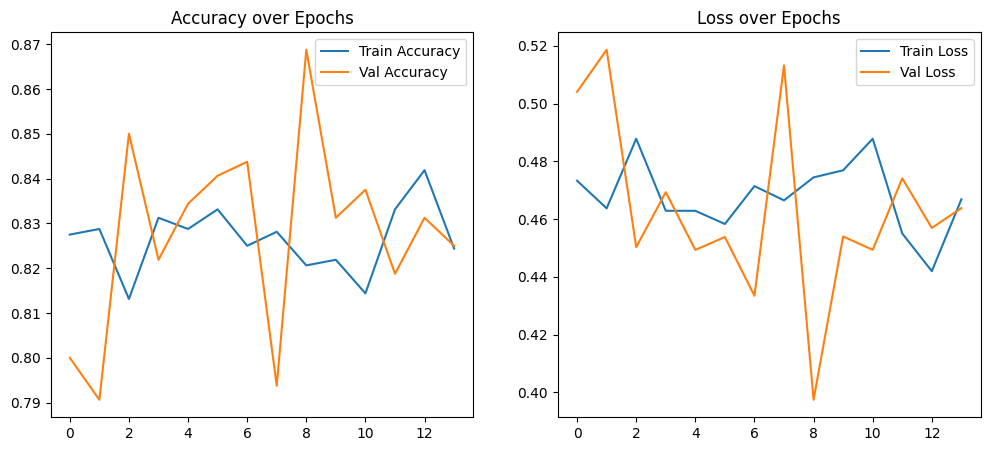

In [18]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.show()

In [19]:
# Predict
y_pred_probs = model.predict(test_gen)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_true = test_gen.classes

# Metrics
test_acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {test_acc:.4f}")
print("\nClassification Report:\n", classification_report(y_true, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))

897/897 ━━━━━━━━━━━━━━━━━━━━ 4147s 5s/step
Test Accuracy: 0.8296

Classification Report:
               precision    recall  f1-score   support

           0       0.83      1.00      0.91     11902
           1       0.00      0.00      0.00      2444

    accuracy                           0.83     14346
   macro avg       0.41      0.50      0.45     14346
weighted avg       0.69      0.83      0.75     14346


Confusion Matrix:
 [[11902     0]
 [ 2444     0]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [20]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import load_model

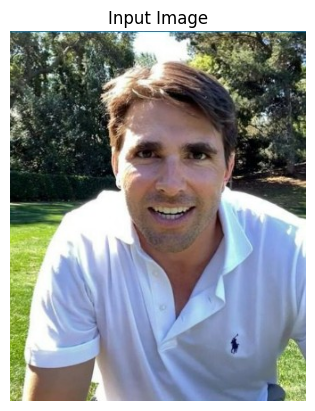

In [28]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def show_image(img_path):
    img = mpimg.imread(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title('Input Image')
    plt.show()

image_path = 'fake_1.jpg'
show_image(image_path)

In [29]:
# Load your trained model
model = load_model('EfficientNetB0_model.h5')

def predict_deepfake(img_path, model, img_size=180, thresh=0.5):

    img = image.load_img(img_path, target_size=(img_size, img_size))
    x = image.img_to_array(img)
    x = np.expand_dims(x, 0)
    x = preprocess_input(x)

    prob = model.predict(x)[0][0]
    label = 'Fake' if prob > thresh else 'Real'

    print(f"Image: {img_path}")
    print(f"→     P(Fake) = {prob:.4f}")
    print(f"→ Prediction = {label}")

predict_deepfake(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Image: real_1.jpg
→     P(Fake) = 0.6506
→ Prediction = Fake
